In [26]:
print("Hello world ")

Hello world 


In [88]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,MinMaxScaler
plt.style.use("default")
sns.set(font_scale=1.1)#select front size by using this  


1.Setup and data loading

we discuss about heart .csv data file and work on it

In [74]:
#import csv file 
df=pd.read_csv('heart.csv')
df.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [29]:
#Basic info about rows, columns, and data types
print('shape :', df.shape)

shape : (918, 12)


In [30]:
print("Info :",df.info())#kono null nei ai database a 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
Info : None


In [31]:
#Quick descriptive statistics for numeric column
df.describe().T#transpose this output matrix using T 

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [32]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [33]:
#define  target and Feature types
target_col='HeartDisease'
numeric_col=['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak']

catagorical_Col=['Sex',"ChestPainType","RestingECG","ExerciseAngina",'ST_Slope']
print(target_col)
print(numeric_col)
print(catagorical_Col)

HeartDisease
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


MISSING VALUES AND BASIC  QUALITY CHECKS 

In [34]:
#check missing value 
df.isna().sum()#there is no missing value 

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [35]:
#Look at some basic value ranges 
df[numeric_col].agg(['min','max','mean','median']).T

,min,max,mean,median
Age,28.0,77.0,53.510893,54.0
RestingBP,0.0,200.0,132.396514,130.0
Cholesterol,0.0,603.0,198.799564,223.0
FastingBS,0.0,1.0,0.233115,0.0
MaxHR,60.0,202.0,136.809368,138.0
Oldpeak,-2.6,6.2,0.887364,0.6


In [36]:
for c in catagorical_Col:
    print(c,df[c].unique())
    #data input deoyar somoy a onk a hoyto bhul korte pare catagorical data 
    # hoyto male, female lekhar somoy sapace diye dise jeta bhul jinish 
    #tai  amader unuque ness thik rakte hobe data distribution ar khetre unique 
    #khuje ber korte hobe amader value gula 

    #m,M,FeMale,male,M, ai bhabe thake pare 
    # onno rokom thakle aikhan a dekha jete  sex a catagorical  value 2 ar jaigay onk gula 

Sex ['M' 'F']
ChestPainType ['ATA' 'NAP' 'ASY' 'TA']
RestingECG ['Normal' 'ST' 'LVH']
ExerciseAngina ['N' 'Y']
ST_Slope ['Up' 'Flat' 'Down']


HISTROGRAM FOR NUMERICAL FEATURE 

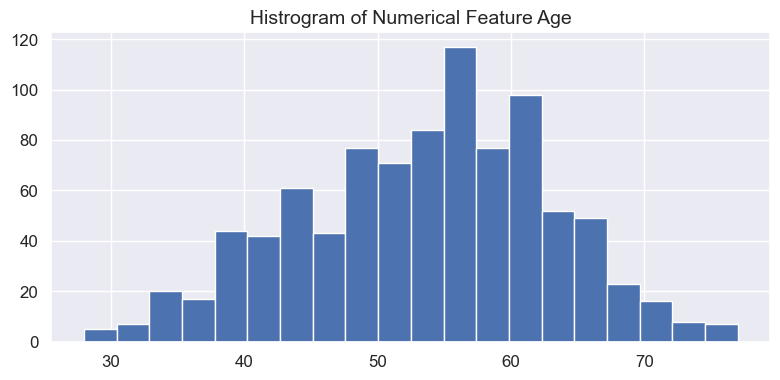

In [37]:
df['Age'].hist(bins=20,figsize=(8,4))
plt.title("Histrogram of Numerical Feature Age",fontsize=14)
plt.tight_layout()
plt.show()#motamoti distributed data 

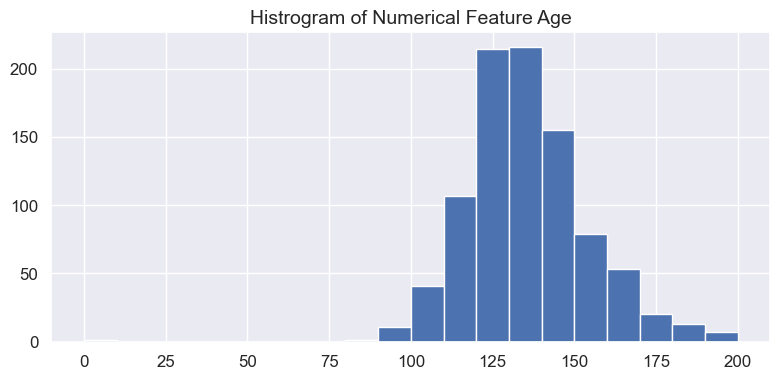

In [38]:
#numerical data visulazation
df['RestingBP'].hist(bins=20,figsize=(8,4))
plt.title("Histrogram of Numerical Feature Age",fontsize=14)
plt.tight_layout()
plt.show()#motamoti distributed data 

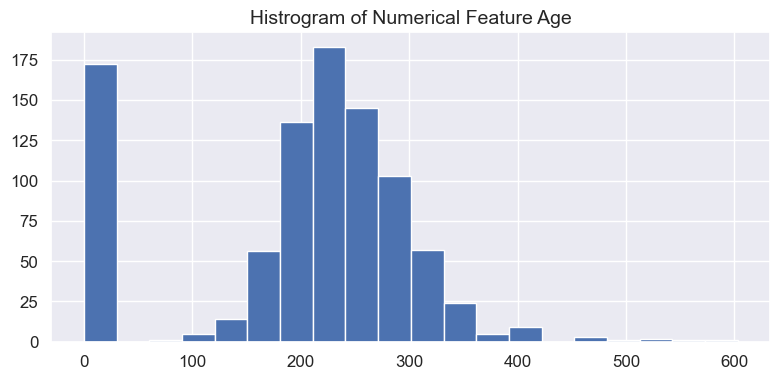

In [39]:
df['Cholesterol'].hist(bins=20,figsize=(8,4))
plt.title("Histrogram of Numerical Feature Age",fontsize=14)
plt.tight_layout()
plt.show()#there is a outliar in this data set cholestrol is not 0 
# there is a outliar

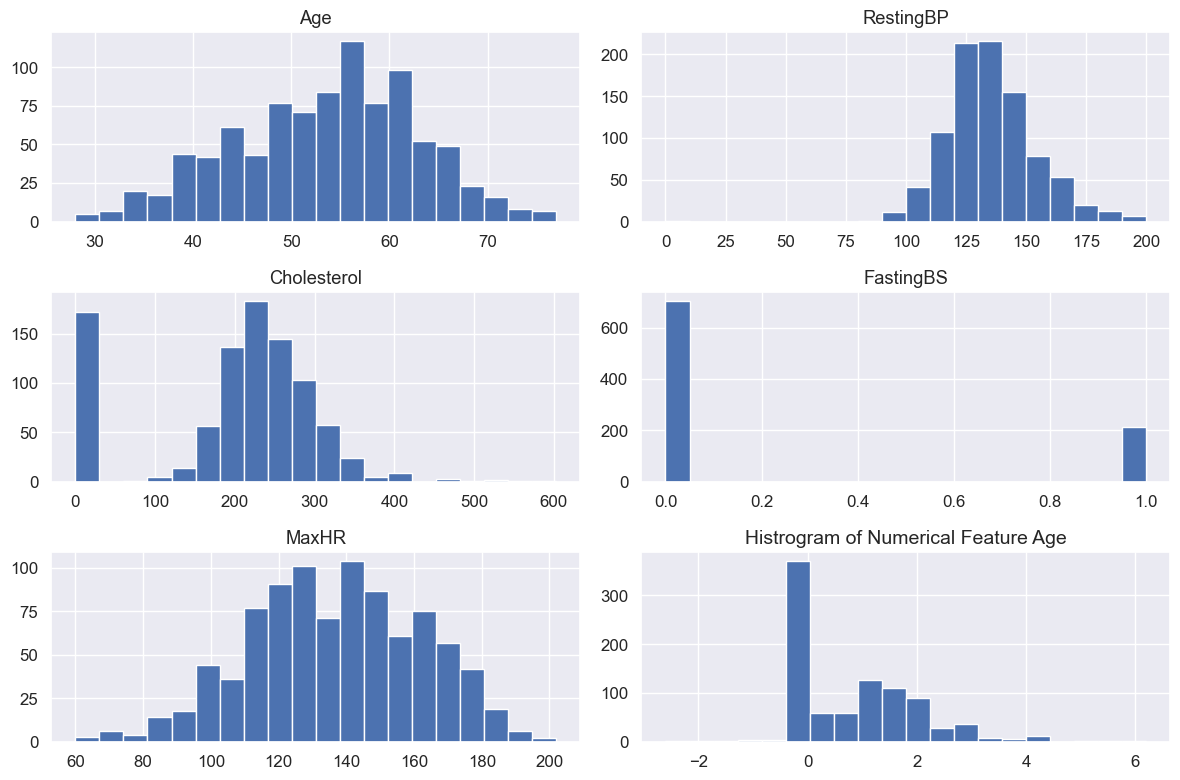

In [40]:
#sob gula numerical feature ar  histrogram dekboo amra ak sathe 
df[numeric_col].hist(bins=20,figsize=(12,8))
plt.title("Histrogram of Numerical Feature Age",fontsize=14)
plt.tight_layout()
plt.show() 

#SEE boxplot to detect outliar in this numeric_column s

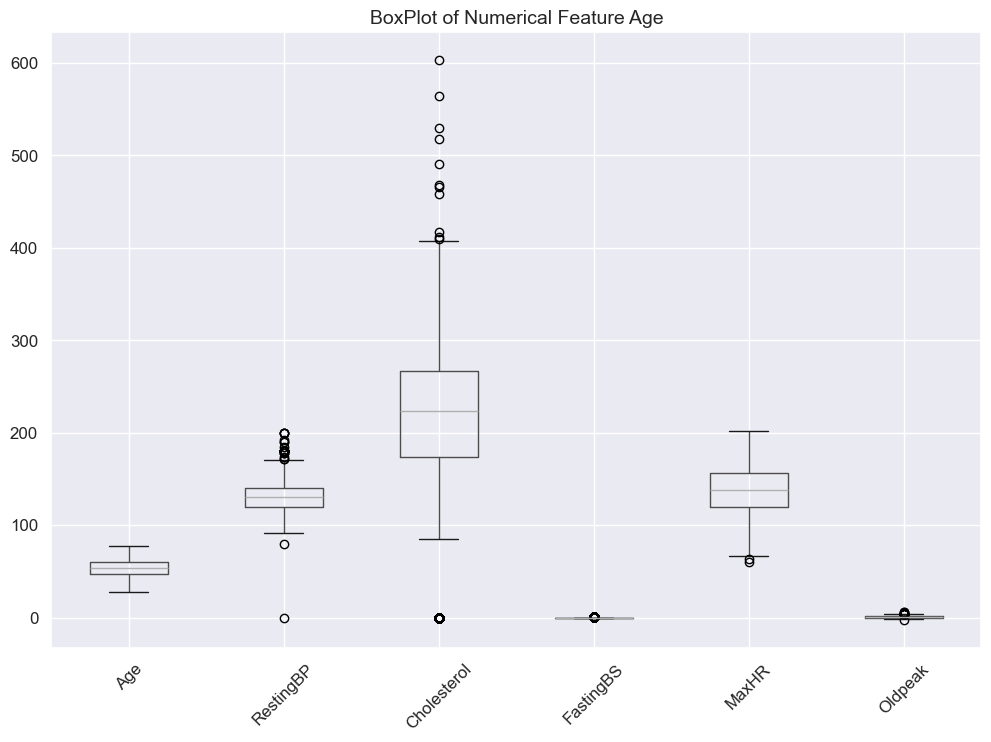

In [41]:
plt.figure(figsize=(12,8))
df[numeric_col].boxplot()
plt.title("BoxPlot of Numerical Feature Age",fontsize=14)
plt.xticks(rotation=45)
plt.show() 

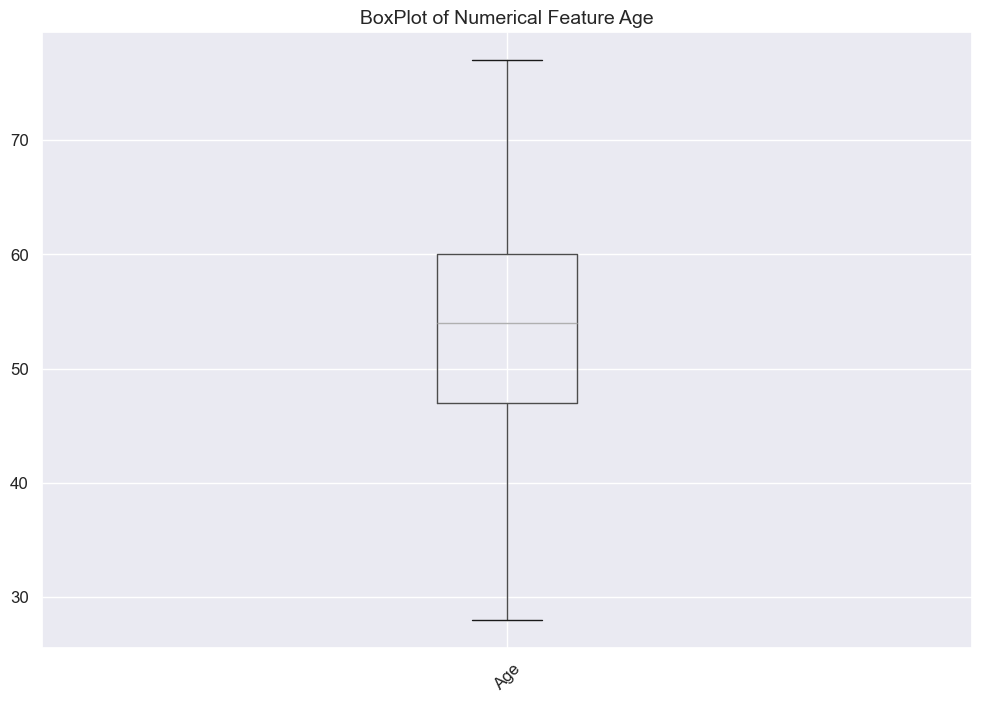

In [42]:
plt.figure(figsize=(12,8))
df.boxplot(column=numeric_col[0])
plt.title("BoxPlot of Numerical Feature Age",fontsize=14)
plt.xticks(rotation=45)
plt.show() #box ar bahirer point gula outliar hobe  

Target Distribution and class imbalance

In [43]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [44]:
df[numeric_col]

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
0,40,140,289,0,172,0.0
1,49,160,180,0,156,1.0
2,37,130,283,0,98,0.0
3,48,138,214,0,108,1.5
4,54,150,195,0,122,0.0
...,...,...,...,...,...,...
913,45,110,264,0,132,1.2
914,68,144,193,1,141,3.4
915,57,130,131,0,115,1.2
916,57,130,236,0,174,0.0


In [45]:
df[catagorical_Col].head(5)

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up


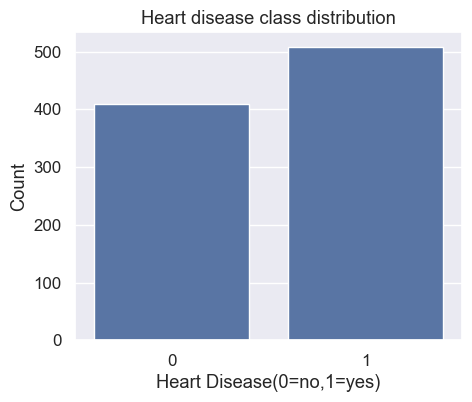

In [46]:
#Target value niye kaj korbo
plt.figure(figsize=(5,4))
sns.countplot(x=df[target_col])
plt.title("Heart disease class distribution")
plt.xlabel("Heart Disease(0=no,1=yes)")
plt.ylabel("Count")
plt.show()


In [47]:
#percentage wise dekbo konta koto percent heartdisease
df[target_col].value_counts(normalize=True)

HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64

CATEGORICAL FEATURE EXPLORATION

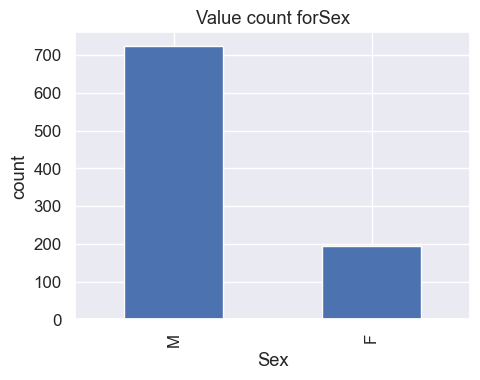

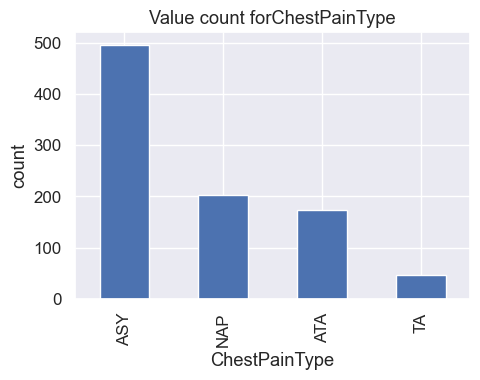

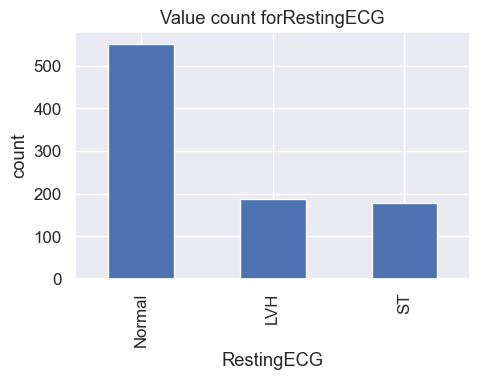

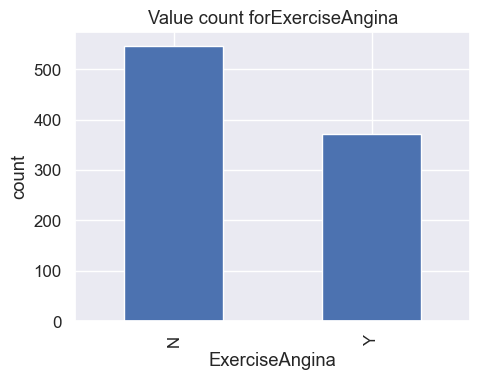

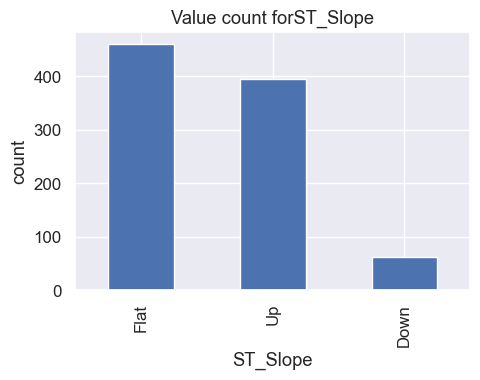

In [48]:
#viwe all categorical feature s
for c in catagorical_Col:
    plt.figure(figsize=(5,4))
    df[c].value_counts().plot(kind="bar")
    plt.title(f"Value count for{c}")
    plt.ylabel("count")

    plt.tight_layout()
    plt.show()

Boxplots of  numeric feature split by HeartDisease

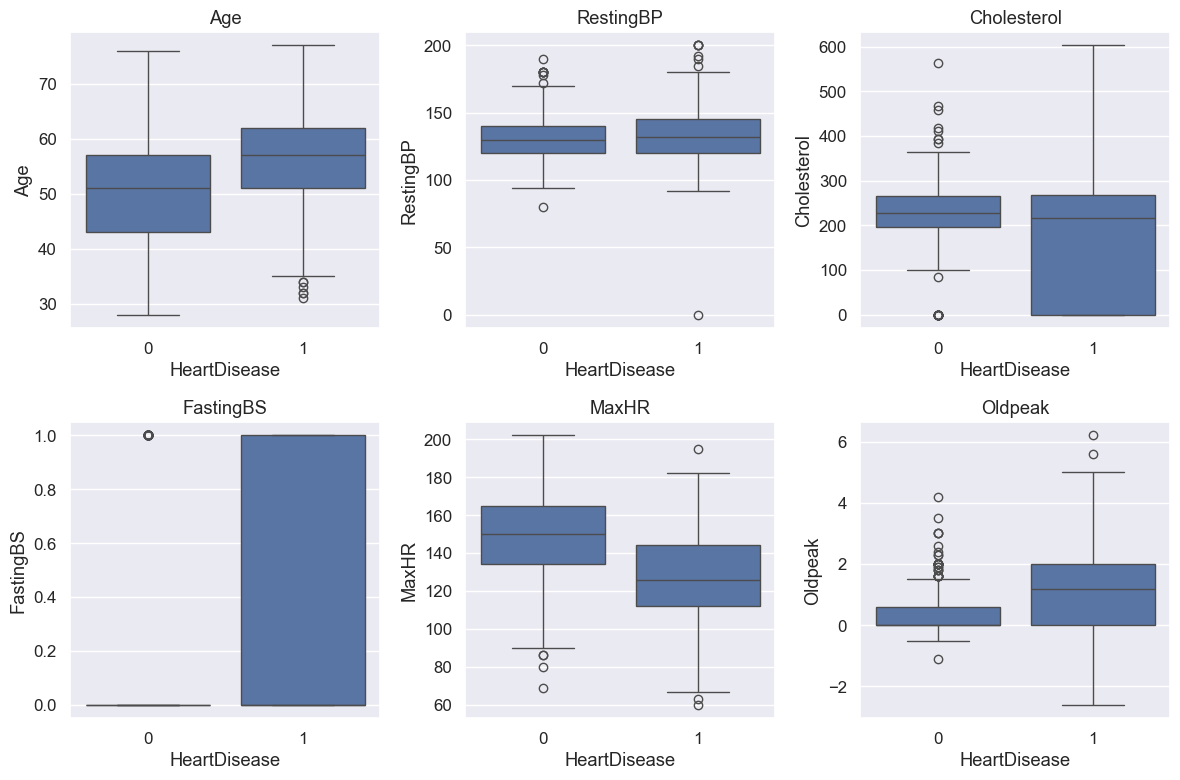

In [49]:
plt.figure(figsize=(12,8))
for i,col in enumerate(numeric_col):
    plt.subplot(2,3,i+1)
    sns.boxplot(x=df[target_col],y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [50]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

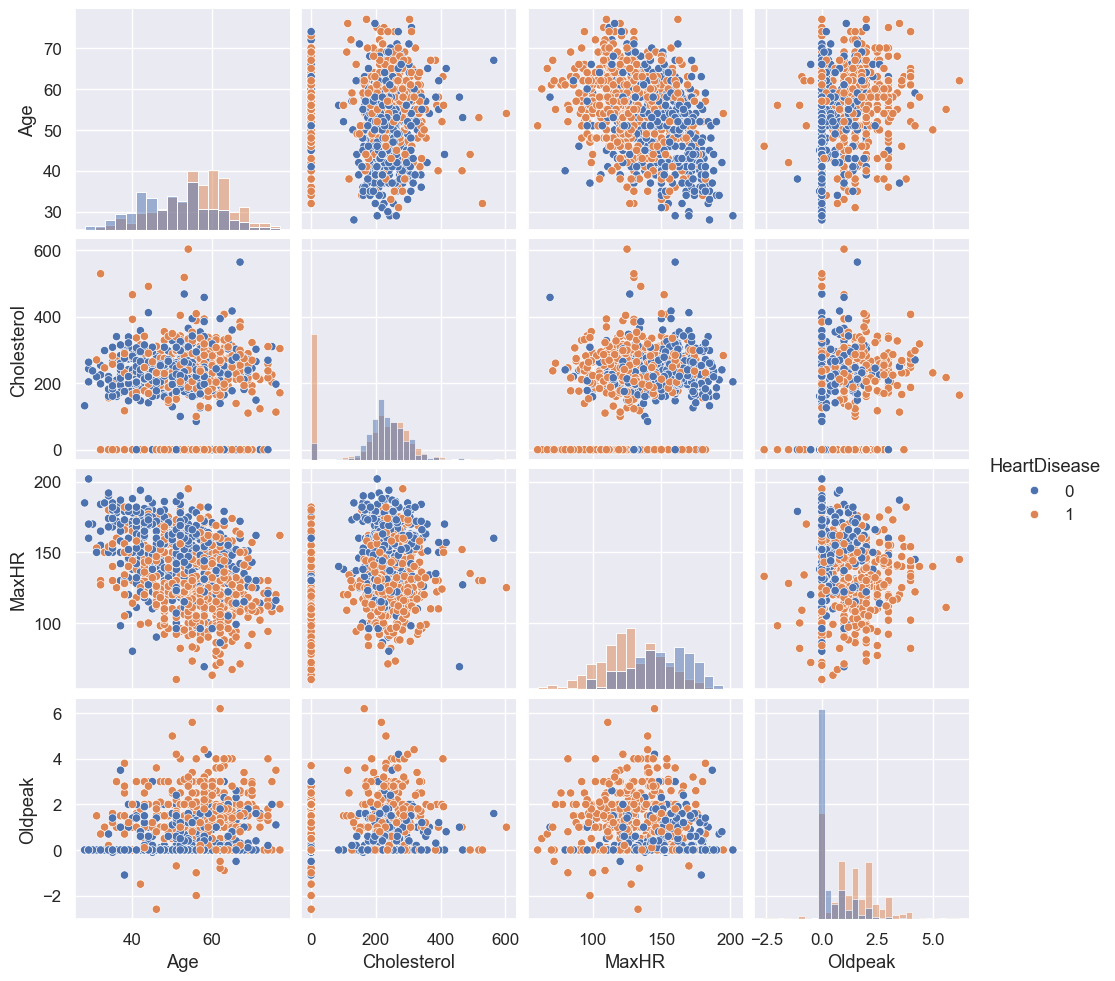

In [51]:
#pairplot for a subset of feature 
sns.pairplot(df[['Age','Cholesterol','MaxHR','Oldpeak','HeartDisease']],hue='HeartDisease',diag_kind='hist')
plt.show()

#Co relation matrix heatup

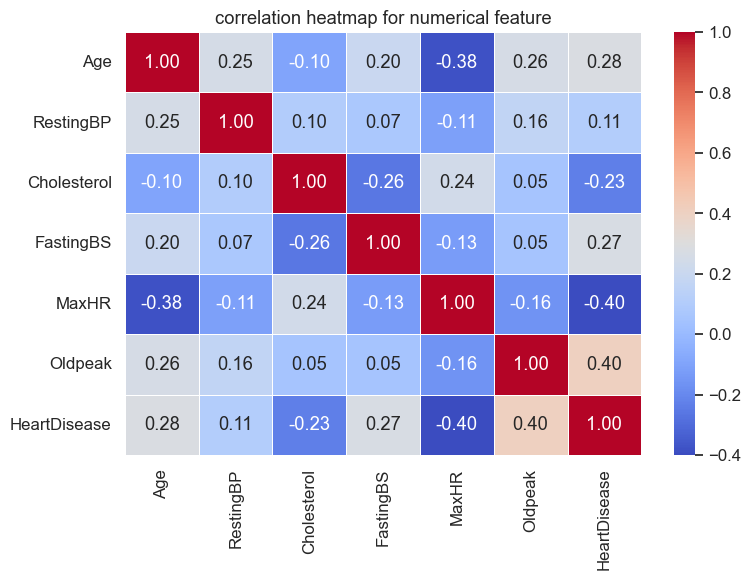

In [52]:
corr_matrix=df[numeric_col+[target_col]].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt='.2f',linewidths=0.5)
plt.title("correlation heatmap for numerical feature")
plt.tight_layout()
plt.show()    

In [53]:
#sort co relation value 

corr_matrix[target_col].sort_values(ascending=False)

HeartDisease    1.000000
Oldpeak         0.403951
Age             0.282039
FastingBS       0.267291
RestingBP       0.107589
Cholesterol    -0.232741
MaxHR          -0.400421
Name: HeartDisease, dtype: float64

Categorical feature vs Target


 Proportion of HeartDisease WithinSex


HeartDisease,0,1
Sex,,
F,0.740933,0.259067
M,0.368276,0.631724


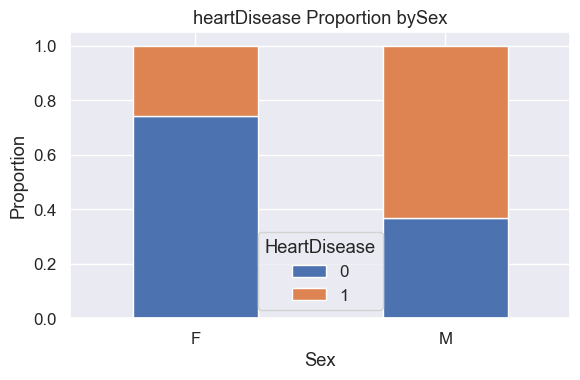


 Proportion of HeartDisease WithinChestPainType


HeartDisease,0,1
ChestPainType,,
ASY,0.209677,0.790323
ATA,0.861272,0.138728
NAP,0.645320,0.354680
TA,0.565217,0.434783


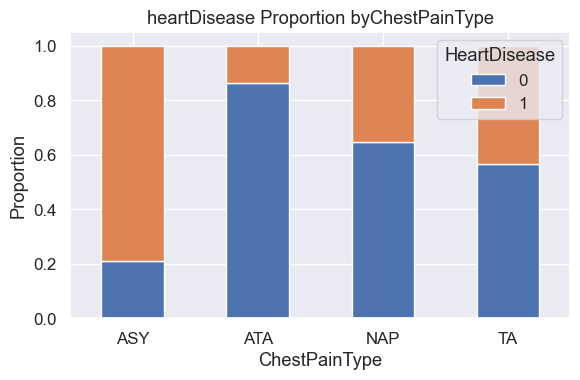


 Proportion of HeartDisease WithinRestingECG


HeartDisease,0,1
RestingECG,,
LVH,0.436170,0.563830
Normal,0.483696,0.516304
ST,0.342697,0.657303


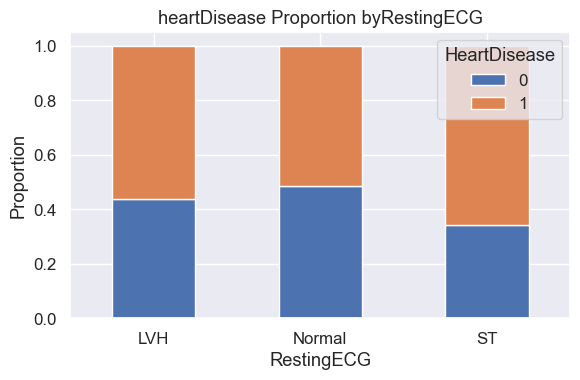


 Proportion of HeartDisease WithinExerciseAngina


HeartDisease,0,1
ExerciseAngina,,
N,0.648995,0.351005
Y,0.148248,0.851752


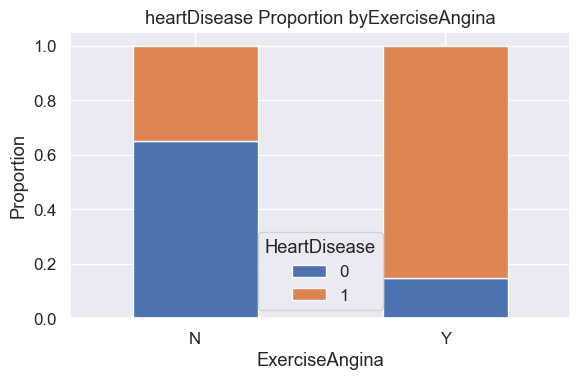


 Proportion of HeartDisease WithinST_Slope


HeartDisease,0,1
ST_Slope,,
Down,0.222222,0.777778
Flat,0.171739,0.828261
Up,0.802532,0.197468


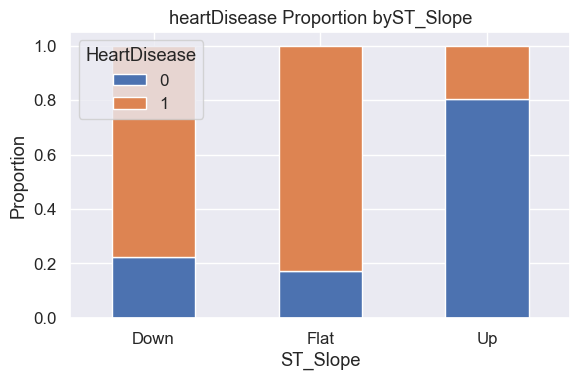

In [54]:
for c in catagorical_Col:
    ct = pd.crosstab(df[c],df[target_col],normalize="index")
    print(f"\n Proportion of HeartDisease Within{c}")
    display(ct)
    ct.plot(kind='bar',stacked=True,figsize=(6,4))
    plt.title(f"heartDisease Proportion by{c}")
    plt.ylabel("Proportion")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

encoding categorical feature in heart dataset 

In [79]:
print(df.head(5))
print(df[catagorical_Col].head(5))

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
  Sex ChestPainType RestingECG ExerciseAngina ST_Slope
0   M           ATA     Normal              N       Up
1   F           NAP     Normal              N     Flat
2   M           ATA         ST            

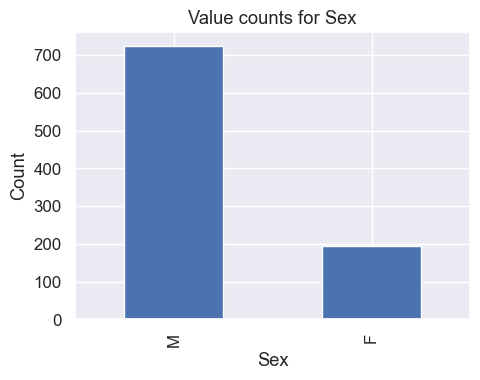

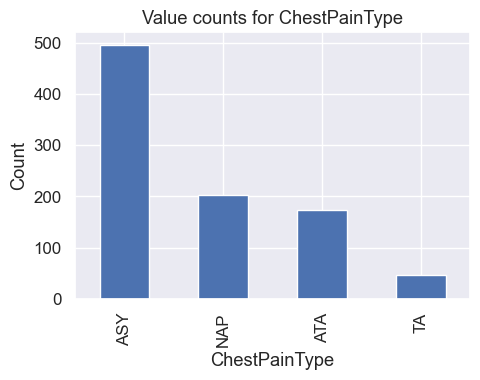

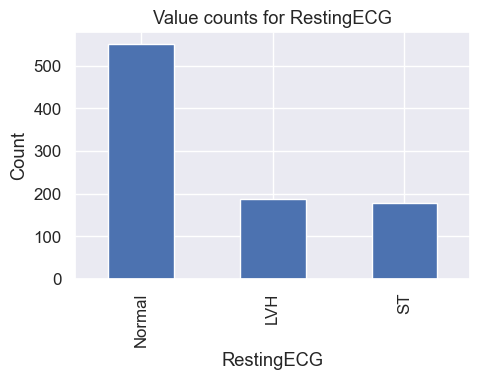

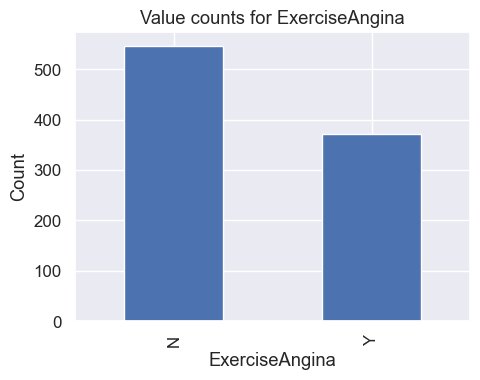

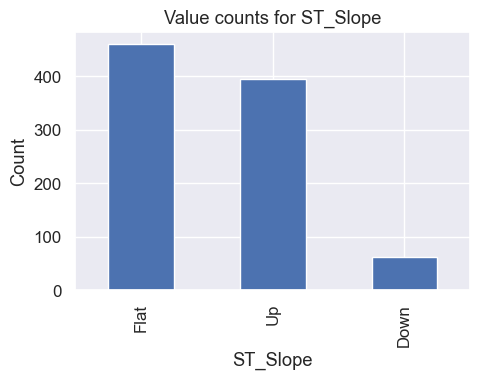

In [80]:
#categorical feature exploration
for c in catagorical_Col:
    plt.figure(figsize=(5,4))
    df[c].value_counts().plot(kind='bar')
    plt.title(f'Value counts for {c}')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

2 ta value thakle binary encoding and multiple value thakle one hot encoding 

korte hobe amader 

In [83]:
#label encoding for binary categorical columns -> sex and ExerciseAngina
le=LabelEncoder()
df['Sex']=le.fit_transform(df['Sex'])
df['ExerciseAngina']=le.fit_transform(df['ExerciseAngina'])
df.head(5)# ai khan a sex column and excercise angina co;umn 0 and 1 
# dhara  replace  hoye gese 

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,0,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,0,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,0,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,1,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,0,0.0,Up,0


#Baki column ar jonno one hot encoding korbo

In [84]:
#One hot encoding for nominal categorical columns
cat_cols=['ChestPainType','RestingECG','ST_Slope']
df_heart_encoded=pd.get_dummies(
    df,columns=cat_cols,
    dtype=int
)

In [ ]:
df_heart_encoded.head(10)# 4 feature gula o binary te convert hoye gese 

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,0,1,0,0,0,1,0,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,0,1,0,0,1,0,0,1,0
2,37,1,130,283,0,98,0,0.0,0,0,1,0,0,0,0,1,0,0,1
3,48,0,138,214,0,108,1,1.5,1,1,0,0,0,0,1,0,0,1,0
4,54,1,150,195,0,122,0,0.0,0,0,0,1,0,0,1,0,0,0,1
5,39,1,120,339,0,170,0,0.0,0,0,0,1,0,0,1,0,0,0,1
6,45,0,130,237,0,170,0,0.0,0,0,1,0,0,0,1,0,0,0,1
7,54,1,110,208,0,142,0,0.0,0,0,1,0,0,0,1,0,0,0,1
8,37,1,140,207,0,130,1,1.5,1,1,0,0,0,0,1,0,0,1,0
9,48,0,120,284,0,120,0,0.0,0,0,1,0,0,0,1,0,0,0,1


Applying min max scaling and standard scaling

amra scale kori dui bhage test data unseen hote hoy 

amader mone rakte hobe je amra sacaling shudu train data set ar uporei korboo 

In [91]:
#assume df_heart_encoded is our working dataframe with  target "HeartDisease"
target_col='HeartDisease'
x=df_heart_encoded.drop(columns=[target_col])
y=df_heart_encoded[target_col]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25,random_state=42)

#standard scaling
scaler_sd=StandardScaler()
x_train_std=scaler_sd.fit_transform(x_train)#mean and sd will be calculated from x_train
x_test_std=scaler_sd.transform(x_test)
x_train_std_df=pd.DataFrame(x_train_std,columns= x_train.columns,index=x_train.index)
print("\n display x train and x test (standard scaled)")
display(x_train_std_df.head())
x_test_std_df=pd.DataFrame(x_test_std,columns= x_test.columns,index=x_test.index)
display(x_test_std_df.head())


 display x train and x test (standard scaled)


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
155,0.239292,0.537019,1.183802,1.307314,1.877849,0.551672,1.182037,1.900458,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064
362,0.239292,0.537019,1.183802,-1.878000,-0.532524,-1.486343,-0.845997,-0.834739,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,-1.225487,2.023931,-0.254981,0.962897,-0.851064
869,0.558968,0.537019,0.913811,0.096522,1.877849,0.831400,-0.845997,0.624033,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
101,-0.293501,0.537019,-0.166155,-0.210833,-0.532524,-1.446382,-0.845997,-0.834739,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
199,0.345851,-1.862131,-0.166155,0.990645,-0.532524,-1.526304,-0.845997,0.076994,-1.104244,-0.480384,-0.530275,4.683304,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
668,0.985202,-1.862131,0.373828,-0.061812,-0.532524,1.710544,-0.845997,-0.834739,-1.104244,2.081666,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999
30,-0.080384,0.537019,0.643819,2.946539,-0.532524,-0.247550,-0.845997,-0.834739,-1.104244,-0.480384,1.885813,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,0.962897,-0.851064
377,1.198319,0.537019,1.453793,-1.878000,1.877849,-0.567238,-0.845997,0.259340,0.905597,-0.480384,-0.530275,-0.213524,-0.505445,-1.225487,2.023931,-0.254981,0.962897,-0.851064
535,0.239292,0.537019,-0.166155,-1.878000,-0.532524,-0.567238,1.182037,0.076994,0.905597,-0.480384,-0.530275,-0.213524,1.978455,-1.225487,-0.494088,-0.254981,0.962897,-0.851064
807,0.026175,0.537019,-1.354116,0.999959,-0.532524,0.791439,-0.845997,-0.834739,-1.104244,2.081666,-0.530275,-0.213524,-0.505445,0.816002,-0.494088,-0.254981,-1.038533,1.174999


In [92]:
#min max scaling
scaler_mm=MinMaxScaler()
x_train_mm=scaler_mm.fit_transform(x_train)
x_test_mm=scaler_mm.transform(x_test)

x_train_mm_df=pd.DataFrame(x_train_mm,columns= x_train.columns,index=x_train.index)
x_test_mm_df=pd.DataFrame(x_test_mm,columns= x_test.columns,index=x_test.index)

display(x_train_mm_df.head())
display(x_test_mm_df.head())
 

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
155,0.562500,1.0,0.775,0.567164,1.0,0.674419,1.0,0.636364,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
362,0.562500,1.0,0.775,0.000000,0.0,0.279070,0.0,0.295455,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
869,0.625000,1.0,0.750,0.351575,1.0,0.728682,0.0,0.477273,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
101,0.458333,1.0,0.650,0.296849,0.0,0.286822,0.0,0.295455,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
199,0.583333,0.0,0.650,0.510779,0.0,0.271318,0.0,0.409091,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
668,0.708333,0.0,0.700,0.323383,0.0,0.899225,0.0,0.295455,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
30,0.500000,1.0,0.725,0.859038,0.0,0.519380,0.0,0.295455,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
377,0.750000,1.0,0.800,0.000000,1.0,0.457364,0.0,0.431818,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
535,0.562500,1.0,0.650,0.000000,0.0,0.457364,1.0,0.409091,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
807,0.520833,1.0,0.540,0.512438,0.0,0.720930,0.0,0.295455,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


PRACTICE A DATA SET OVERALL SET UP AND 

PRACTICE DATA SET WHICH IS IN CLUDE WITH MISSING VALUE AND MISSING VALUE IN COLUMN AND ALSO INCLUDE WITH CATAGORICAL VALUE AND ALSO 

SHOWING HOW TO HANDLE THIS CATAGORICAL VALUE WITH ENCODING  AND ALSO  Z SCORE AND MIN MAX SCALING AND HOW TO CONTROL OUTLIAR

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
plt.style.use("default")
sns.set(font_scale=1.1)

In [56]:
df=pd.read_csv("Titanic-Dataset.csv")
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [57]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [59]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [60]:
df.shape

(891, 12)

In [61]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [62]:
print("Unique Values per column ")
df.nunique()

Unique Values per column 


PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

HANDELING MISSING VALUE 

THERE ARE MULTIPLE TECQNIC TO ADJUST MISSING VALUE 

MEAN ,MEDIAN , FREQUENCY AND MODE

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [64]:
print("Missing values per column ")
df.isnull().sum()#amader jdi maximum data jdi missing e thake tahole oi column 
# amader delete kore deoyai  vhalo jemon cabin a 900 datar modde 687 data missing
# tai amader ai column delete kore deoyai bhalo

Missing values per column 


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

DISTRIBUTION OF AGE COLUMN

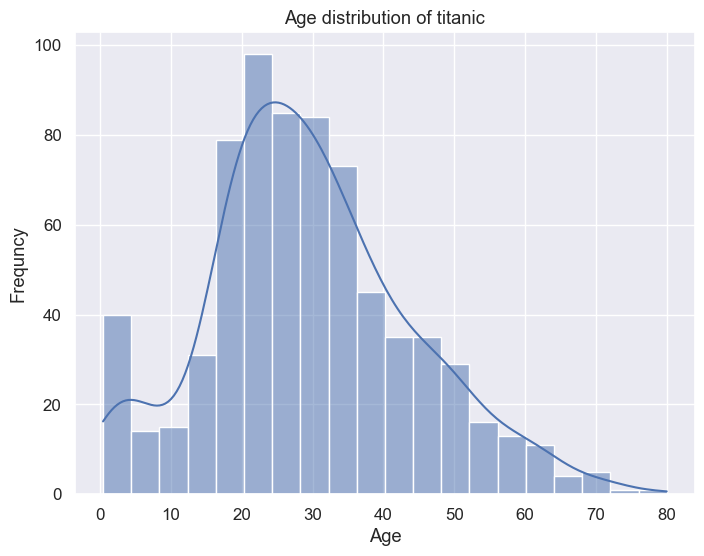

In [65]:
plt.figure(figsize=(8,6))
sns.histplot(df['Age'],kde=True,bins=20)
#kde dile amara bujte pari data kon dike flow hosse 
plt.title("Age distribution of titanic")
plt.xlabel("Age")
plt.ylabel("Frequncy")
plt.show()
#we wiill use median as the  feature values are right skewed
#if left skewed than use mean value for missing value

In [66]:
df["Age"].mean()#if our data is left skewed than we use mean value for 
#handeling missing data 

np.float64(29.69911764705882)

In [67]:
df["Age"].median()#our data is right skewed so we use median value for data missing data

28.0

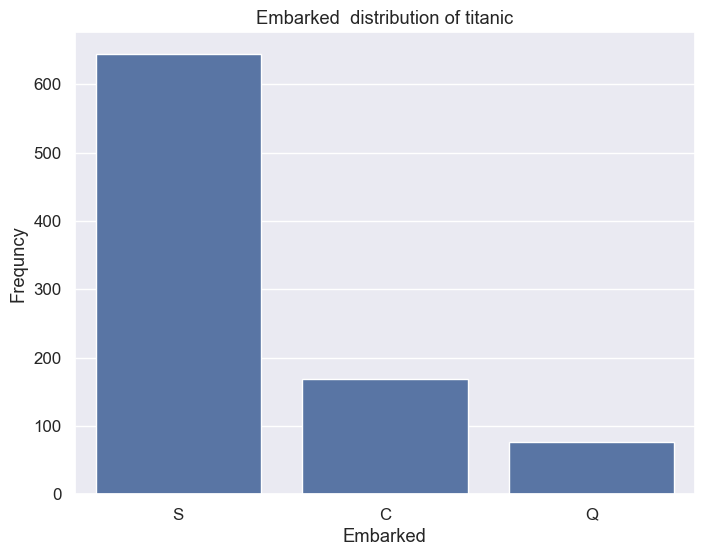

In [68]:
#embarke is categorical value  so we use mode frequency 
plt.figure(figsize=(8,6))
sns.countplot(data=df,x='Embarked')
#kde dile amara bujte pari data kon dike flow hosse 
plt.title("Embarked  distribution of titanic")
plt.xlabel("Embarked")
plt.ylabel("Frequncy")
plt.show()#there ase three embarke S , C ,Q


Our the column is missing value age , embarke and  cabin 

ahere cabin is maximum value is missing so we delete the overall cabin column 

then we fullfill the age column with missing value is median 

then we fullfill the embarke column with mode because its a categorical feature 
 

In [69]:
#Handeling missing value age 
age_median= df["Age"].median()

df['Age']=df['Age'].fillna(age_median)
#2. handle categorical missing values : Embarked
embarked_Mode=df['Embarked'].mode()[0]
df['Embarked']=df['Embarked'].fillna(embarked_Mode)
##.3. Drop cabin (Too many missing value ):
df=df.drop(columns=['Cabin'])

Now check the hole missing values

In [70]:
print("Missing value after handeling ")
df.isnull().sum()
# now there are no missing values 

Missing value after handeling 


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Encoding Categorical Variables or Feature